# testing for Henry

In [11]:
import tempfile
import numpy as np
import rxembed as rx
import xyzrender
from rdkit import RDLogger
from rdkit.Chem import rdMolTransforms as T
from rxembed.constraints.metal import metal_indices
from rxembed.embed.dispatch import _xyz_to_mol

RDLogger.DisableLog("rdApp.*")
rx.set_verbose("INFO")


def xyz(ens):
    return ens.lowest(1).dump(tempfile.mktemp(suffix=".xyz"))  # 1 conformer -> a path xyzrender reads


def mxyz(ens):
    return ens.dump(tempfile.mktemp(suffix=".xyz"))

In [12]:
smi_pairs = [
    [
        "CC[P]1(CC)CC[P](CC)(CC)->[Ni+2]<-12<-[O-]C(=O)C(c1ccccc1)[N-]->2c1ccccc1",
        "CC[P]1(CC)CC[P](CC)(CC)->[Ni+2]<-12<-[O-]C(=O)N(c1ccccc1)[CH-]->2c1ccccc1",
    ],
    [
        "C[N]1(C)NC(N)=[S]->[Ni+2]<-12<-[O-]C(=O)C(c1ccccc1)[N-]->2c1ccccc1",
        "C[N]1(C)NC(N)=[S]->[Ni+2]<-12<-[O-]C(=O)N(c1ccccc1)[CH-]->2c1ccccc1",
    ],
    [
        "CNC1N[N](C)(C)->[Ni+2]2(<-[O-]C(=O)C(c3ccccc3)[N-]->2c2ccccc2)<-[S]=1",
        "CNC1N[N](C)(C)->[Ni+2]2(<-[O-]C(=O)N(c3ccccc3)[CH-]->2c2ccccc2)<-[S]=1",
    ],
    [
        "CCNC1N[NH2]->[Ni+2]2(<-[O-]C(=O)C(c3ccccc3)[N-]->2c2ccccc2)<-[S]=1",
        "CCNC1N[NH2]->[Ni+2]2(<-[O-]C(=O)N(c3ccccc3)[CH-]->2c2ccccc2)<-[S]=1",
    ],
    [
        "O=C1[O-]->[Ni+2]2(<-[N-](c3ccccc3)C1c1ccccc1)<-[P](CC[P]->2(c1ccccc1)c1ccccc1)(c1ccccc1)c1ccccc1",
        "O=C1[O-]->[Ni+2]2(<-[CH-](c3ccccc3)N1c1ccccc1)<-[P](CC[P]->2(c1ccccc1)c1ccccc1)(c1ccccc1)c1ccccc1",
    ],
    [
        "O=C1[O-]->[Ni+2]2(<-[N](O)=C(c3ccccn3)c3cccc[n]->23)<-[N-](c2ccccc2)C1c1ccccc1",
        "O=C1[O-]->[Ni+2]2(<-[CH-](c3ccccc3)N1c1ccccc1)<-[N](O)=C(c1ccccn1)c1cccc[n]->21",
    ],
    [
        "O=C1[O-]->[Ni+2]2(<-[n]3cccc4ccc5ccc[n]->2c5c43)<-[N-](c2ccccc2)C1c1ccccc1",
        "O=C1[O-]->[Ni+2]2(<-[CH-](c3ccccc3)N1c1ccccc1)<-[n]1cccc3ccc4ccc[n]->2c4c31",
    ],
    [
        "O=C1C(=O)c2ccc[n]3->[Ni+2]4(<-[O-]C(=O)C(c5ccccc5)[N-]->4c4ccccc4)<-[n]4cccc1c4-c23",
        "O=C1C(=O)c2ccc[n]3->[Ni+2]4(<-[O-]C(=O)N(c5ccccc5)[CH-]->4c4ccccc4)<-[n]4cccc1c4-c23",
    ],
    [
        "O=C1[O-]->[Ni+2]2(<-[n]3ccccc3-c3cn(C4CCCCC4)n[n]->23)<-[N-](c2ccccc2)C1c1ccccc1",
        "O=C1[O-]->[Ni+2]2(<-[CH-](c3ccccc3)N1c1ccccc1)<-[n]1ccccc1-c1cn(C3CCCCC3)n[n]->21",
    ],
    [
        "CC(C)[P]1(CC[P](C(C)C)(C(C)C)->[Ni+2]<-12<-[O-]C(=O)C(c1ccccc1)[N-]->2c1ccccc1)C(C)C",
        "CC(C)[P]1(CC[P](C(C)C)(C(C)C)->[Ni+2]<-12<-[O-]C(=O)N(c1ccccc1)[CH-]->2c1ccccc1)C(C)C",
    ],
    [
        "COC(=O)C1=C(C(=O)OC)[P]2(->[Ni+2]3(<-[O-]C(=O)C(c4ccccc4)[N-]->3c3ccccc3)<-[P]1(c1ccccc1)c1ccccc1)N(Cc1ccccc1)C1CCCCC1N2Cc1ccccc1",
        "COC(=O)C1=C(C(=O)OC)[P]2(->[Ni+2]3(<-[O-]C(=O)N(c4ccccc4)[CH-]->3c3ccccc3)<-[P]1(c1ccccc1)c1ccccc1)N(Cc1ccccc1)C1CCCCC1N2Cc1ccccc1",
    ],
    [
        "CC1N(Cc2ccccc2)c2cccc[n]2->[Ni+2]2(<-[O-]C(=O)C(c3ccccc3)[N-]->2c2ccccc2)<-[N]=1c1c(C(C)C)cccc1C(C)C",
        "CC1N(Cc2ccccc2)c2cccc[n]2->[Ni+2]2(<-[O-]C(=O)N(c3ccccc3)[CH-]->2c2ccccc2)<-[N]=1c1c(C(C)C)cccc1C(C)C",
    ],
    [
        "CC1CC(C)=[O]->[Ni+2]2(<-[O]=1)<-[O-]C(=O)C(c1ccccc1)[N-]->2c1ccccc1",
        "CC1CC(C)=[O]->[Ni+2]2(<-[O]=1)<-[O-]C(=O)N(c1ccccc1)[CH-]->2c1ccccc1",
    ],
    [
        "CCOC1=[O]->[Ni+2]2(<-[O-]C(=O)C(c3ccccc3)[N-]->2c2ccccc2)<-[n]2c[nH]c(C)c21",
        "CCOC1=[O]->[Ni+2]2(<-[O-]C(=O)N(c3ccccc3)[CH-]->2c2ccccc2)<-[n]2c[nH]c(C)c21",
    ],
    [
        "CC[P]1(CC)CC[P](c2ccccc2)(c2ccccc2)->[Ni+2]<-12<-[O-]C(=O)C(c1ccccc1)[N-]->2c1ccccc1",
        "CC[P]1(CC)CC[P](c2ccccc2)(c2ccccc2)->[Ni+2]<-12<-[O-]C(=O)N(c1ccccc1)[CH-]->2c1ccccc1",
    ],
    [
        "O=C1[O-]->[Ni+2]2(<-[N](=CC=Cc3ccccc3[N+](=O)[O-])CC[N]->2=CC=Cc2ccccc2[N+](=O)[O-])<-[N-](c2ccccc2)C1c1ccccc1",
        "O=C1[O-]->[Ni+2]2(<-[CH-](c3ccccc3)N1c1ccccc1)<-[N](=CC=Cc1ccccc1[N+](=O)[O-])CC[N]->2=CC=Cc1ccccc1[N+](=O)[O-]",
    ],
    [
        "O=C1[O-]->[Ni+2]2(<-[N-](c3ccccc3)C1c1ccccc1)<-[P](C=C[P]->2(c1ccccc1)c1ccccc1)(c1ccccc1)c1ccccc1",
        "O=C1[O-]->[Ni+2]2(<-[CH-](c3ccccc3)N1c1ccccc1)<-[P](C=C[P]->2(c1ccccc1)c1ccccc1)(c1ccccc1)c1ccccc1",
    ],
    [
        "CCCCCCc1cccc2-c3cccc[n]3->[Ni+2]3(<-[O-]C(=O)C(c4ccccc4)[N-]->3c3ccccc3)<-[n]12",
        "CCCCCCc1cccc2-c3cccc[n]3->[Ni+2]3(<-[O-]C(=O)N(c4ccccc4)[CH-]->3c3ccccc3)<-[n]12",
    ],
    [
        "Cc1cc(-c2ccccc2)cc2-c3cc(-c4ccccc4)cc(C)[n]3->[Ni+2]3(<-[O-]C(=O)C(c4ccccc4)[N-]->3c3ccccc3)<-[n]12",
        "Cc1cc(-c2ccccc2)cc2-c3cc(-c4ccccc4)cc(C)[n]3->[Ni+2]3(<-[O-]C(=O)N(c4ccccc4)[CH-]->3c3ccccc3)<-[n]12",
    ],
    [
        "O=C1[O-]->[Ni+2]2(<-[NH2]CC[NH2]->2)<-[N-](c2ccccc2)C1c1ccccc1",
        "O=C1[O-]->[Ni+2]2(<-[NH2]CC[NH2]->2)<-[CH-](c2ccccc2)N1c1ccccc1",
    ],
    [
        "CC1(C)C2CCC1(C)C([N]1=C3C(=[N](C4CC5CCC4(C)C5(C)C)->[Ni+2]<-14<-[O-]C(=O)C(c1ccccc1)[N-]->4c1ccccc1)c1cccc4cccc3c14)C2",
        "CC1(C)C2CCC1(C)C([N]1=C3C(=[N](C4CC5CCC4(C)C5(C)C)->[Ni+2]<-14<-[O-]C(=O)N(c1ccccc1)[CH-]->4c1ccccc1)c1cccc4cccc3c14)C2",
    ],
    [
        "Cc1c[n]2->[Ni+2]3(<-[O-]C(=O)C(c4ccccc4)[N-]->3c3ccccc3)<-[n]3cc(C)c(C)c4ccc(c1C)c2c43",
        "Cc1c[n]2->[Ni+2]3(<-[O-]C(=O)N(c4ccccc4)[CH-]->3c3ccccc3)<-[n]3cc(C)c(C)c4ccc(c1C)c2c43",
    ],
    [
        "O=C1[O-]->[Ni+2]2(<-[N-](c3ccccc3)C1c1ccccc1)<-[P](c1ccccc1)(c1ccccc1)c1ccccc1[P]->2(c1ccccc1)c1ccccc1",
        "O=C1[O-]->[Ni+2]2(<-[CH-](c3ccccc3)N1c1ccccc1)<-[P](c1ccccc1)(c1ccccc1)c1ccccc1[P]->2(c1ccccc1)c1ccccc1",
    ],
    [
        "Cc1ccc2-c3ccc(C)c[n]3->[Ni+2]3(<-[O-]C(=O)C(c4ccccc4)[N-]->3c3ccccc3)<-[n]2c1",
        "Cc1ccc2-c3ccc(C)c[n]3->[Ni+2]3(<-[O-]C(=O)N(c4ccccc4)[CH-]->3c3ccccc3)<-[n]2c1",
    ],
    [
        "Cc1cc(C)c(N2C=CN3CC[NH](C(C)(C)C)->[Ni+2]4(<-[O-]C(=O)C(c5ccccc5)[N-]->4c4ccccc4)<-[C]32)c(C)c1",
        "Cc1cc(C)c(N2C=CN3CC[NH](C(C)(C)C)->[Ni+2]4(<-[O-]C(=O)N(c5ccccc5)[CH-]->4c4ccccc4)<-[C]32)c(C)c1",
    ],
    [
        "O=C1[O-]->[Ni+2]2(<-[OH]Cc3cccc[n]->23)<-[N-](c2ccccc2)C1c1ccccc1",
        "O=C1[O-]->[Ni+2]2(<-[OH]Cc3cccc[n]->23)<-[CH-](c2ccccc2)N1c1ccccc1",
    ],
    [
        "O=C1[O-]->[Ni+2]2(<-[NH2]C3CCCCC3[NH2]->2)<-[N-](c2ccccc2)C1c1ccccc1",
        "O=C1[O-]->[Ni+2]2(<-[NH2]C3CCCCC3[NH2]->2)<-[CH-](c2ccccc2)N1c1ccccc1",
    ],
    [
        "CCC1=C2CCCCC2=C(CC)[P](c2ccccc2)(c2ccccc2)->[Ni+2]2(<-[O-]C(=O)C(c3ccccc3)[N-]->2c2ccccc2)<-[P]1(c1ccccc1)c1ccccc1",
        "CCC1=C2CCCCC2=C(CC)[P](c2ccccc2)(c2ccccc2)->[Ni+2]2(<-[O-]C(=O)N(c3ccccc3)[CH-]->2c2ccccc2)<-[P]1(c1ccccc1)c1ccccc1",
    ],
    [
        "CCC1=C2CC3OC(C)(OC)C(C)(OC)OC3CC2=C(CC)[P](c2ccccc2)(c2ccccc2)->[Ni+2]2(<-[O-]C(=O)C(c3ccccc3)[N-]->2c2ccccc2)<-[P]1(c1ccccc1)c1ccccc1",
        "CCC1=C2CC3OC(C)(OC)C(C)(OC)OC3CC2=C(CC)[P](c2ccccc2)(c2ccccc2)->[Ni+2]2(<-[O-]C(=O)N(c3ccccc3)[CH-]->2c2ccccc2)<-[P]1(c1ccccc1)c1ccccc1",
    ],
    [
        "O=C1[O-]->[Ni+2]2(<-[NH2]CCc3c[nH]c[n]->23)<-[N-](c2ccccc2)C1c1ccccc1",
        "O=C1[O-]->[Ni+2]2(<-[NH2]CCc3c[nH]c[n]->23)<-[CH-](c2ccccc2)N1c1ccccc1",
    ],
    [
        "CC1C(C)=[N](c2ccc(C)cc2)->[Ni+2]2(<-[O-]C(=O)C(c3ccccc3)[N-]->2c2ccccc2)<-[N]=1[O]",
        "CC1C(C)=[N](c2ccc(C)cc2)->[Ni+2]2(<-[O-]C(=O)N(c3ccccc3)[CH-]->2c2ccccc2)<-[N]=1[O]",
    ],
    [
        "CC1C(C)=[N](c2ccc(C)cc2)->[Ni+2]2(<-[O-]C(=O)C(c3ccccc3)[N-]->2c2ccccc2)<-[N]=1O",
        "CC1C(C)=[N](c2ccc(C)cc2)->[Ni+2]2(<-[O-]C(=O)N(c3ccccc3)[CH-]->2c2ccccc2)<-[N]=1O",
    ],
    [
        "O=C1[O-]->[Ni+2]2(<-[N](=C3C(=[N]->2c2cccc4ccccc24)c2cccc4cccc3c24)c2cccc3ccccc23)<-[N-](c2ccccc2)C1c1ccccc1",
        "O=C1[O-]->[Ni+2]2(<-[CH-](c3ccccc3)N1c1ccccc1)<-[N](=C1C(=[N]->2c2cccc3ccccc23)c2cccc3cccc1c23)c1cccc2ccccc12",
    ],
    [
        "COc1ccc([N]2=C3C(=[N](c4ccc(OC)cc4)->[Ni+2]<-24<-[O-]C(=O)C(c2ccccc2)[N-]->4c2ccccc2)c2cccc4cccc3c24)cc1",
        "COc1ccc([N]2=C3C(=[N](c4ccc(OC)cc4)->[Ni+2]<-24<-[O-]C(=O)N(c2ccccc2)[CH-]->4c2ccccc2)c2cccc4cccc3c24)cc1",
    ],
]

In [13]:
old_smi_pairs = [
    [
        "Cc1cc(C)c(N2C=CN3CCN4C=CN(c5c(C)cc(C)cc5C)[C]4->[Ni+2]4(<-[O-]C(=O)C(c5ccccc5)[N-]->4c4ccccc4)<-[C]32)c(C)c1",
        "Cc1cc(C)c(N2C=CN3CCN4C=CN(c5c(C)cc(C)cc5C)[C]4->[Ni+2]4(<-[O-]C(=O)N(c5ccccc5)[CH-]->4c4ccccc4)<-[C]32)c(C)c1",
    ],
    [
        "Cc1cc(C)c([CH]2=[PH]->[Ni+2]<-23<-[O-]C(=O)C(c2ccccc2)[N-]->3c2ccccc2)c(C)c1",
        "Cc1cc(C)c([CH]2=[PH]->[Ni+2]<-23<-[O-]C(=O)N(c2ccccc2)[CH-]->3c2ccccc2)c(C)c1",
    ],
    [
        "O=C1[O-]->[Ni+2]2(<-[N-](c3ccccc3)C1c1ccccc1)<-[P](Cc1ccccc1[P]->2(C1CCCCC1)C1CCCCC1)(C1CCCCC1)C1CCCCC1",
        "O=C1[O-]->[Ni+2]2(<-[CH-](c3ccccc3)N1c1ccccc1)<-[P](Cc1ccccc1[P]->2(C1CCCCC1)C1CCCCC1)(C1CCCCC1)C1CCCCC1",
    ],
    [
        "CC(C)(C)[N]1=[CH](Cc2ccccc2)->[Ni+2]<-12<-[O-]C(=O)C(c1ccccc1)[N-]->2c1ccccc1",
        "CC(C)(C)[N]1=[CH](Cc2ccccc2)->[Ni+2]<-12<-[O-]C(=O)N(c1ccccc1)[CH-]->2c1ccccc1",
    ],
    [
        "CSC1N=[N](c2ccccc2)->[Ni+2]2(<-[NH]=1)<-[O-]C(=O)C(c1ccccc1)[N-]->2c1ccccc1",
        "CSC1N=[N](c2ccccc2)->[Ni+2]2(<-[NH]=1)<-[O-]C(=O)N(c1ccccc1)[CH-]->2c1ccccc1",
    ],
    [
        "O=C1[O-]->[Ni+2]2(<-[N](=C3C(=[N]->2c2cccc4ccccc24)c2cccc4cccc3c24)c2cccc3ccccc23)<-[N-](c2ccccc2)C1c1ccccc1",
        "O=C1[O-]->[Ni+2]2(<-[CH-](c3ccccc3)N1c1ccccc1)<-[N](=C1C(=[N]->2c2cccc3ccccc23)c2cccc3cccc1c23)c1cccc2ccccc12",
    ],
    [
        "O=C1[O-]->[Ni+2]2(<-[N](=C3C(=[N]->2c2c(-c4cc(C(F)(F)F)cc(C(F)(F)F)c4)cccc2-c2cc(C(F)(F)F)cc(C(F)(F)F)c2)C2c4ccccc4C3c3ccccc32)c2ccccc2)<-[N-](c2ccccc2)C1c1ccccc1",
        "O=C1[O-]->[Ni+2]2(<-[CH-](c3ccccc3)N1c1ccccc1)<-[N](=C1C(=[N]->2c2c(-c3cc(C(F)(F)F)cc(C(F)(F)F)c3)cccc2-c2cc(C(F)(F)F)cc(C(F)(F)F)c2)C2c3ccccc3C1c1ccccc12)c1ccccc1",
    ],
    [
        "CC(C)(C)[C]1#[C](C#C[Si](C)(C)C)->[Ni+2]<-12<-[O-]C(=O)C(c1ccccc1)[N-]->2c1ccccc1",
        "CC(C)(C)[C]1#[C](C#C[Si](C)(C)C)->[Ni+2]<-12<-[O-]C(=O)N(c1ccccc1)[CH-]->2c1ccccc1",
    ],
    [
        "Cc1cc(C)c([N]2=C3C(=[N](c4c(C)cccc4C)->[Ni+2]<-24<-[O-]C(=O)C(c2ccccc2)[N-]->4c2ccccc2)c2cccc4cccc3c24)c(C(c2ccc(F)cc2)c2ccc(F)cc2)c1",
        "Cc1cc(C)c([N]2=C3C(=[N](c4c(C)cccc4C)->[Ni+2]<-24<-[O-]C(=O)N(c2ccccc2)[CH-]->4c2ccccc2)c2cccc4cccc3c24)c(C(c2ccc(F)cc2)c2ccc(F)cc2)c1",
    ],
    [
        "COC(=O)[C]12->[Ni+2]3(<-[O-]C(=O)C(c4ccccc4)[N-]->3c3ccccc3)<-[C]=1(C(=O)OC)C2(C)C(C)(C)C",
        "COC(=O)[C]12->[Ni+2]3(<-[O-]C(=O)N(c4ccccc4)[CH-]->3c3ccccc3)<-[C]=1(C(=O)OC)C2(C)C(C)(C)C",
    ],
]

rxembed | metal: 1 undefined ligand stereocentre(s) -> enumerating coordination x 2 ligand stereoisomer(s) = 4 candidate(s) (select stereo=)


  [0] square_planar    S6 N1 O8 N18               (achiral)  stereo 11S
  [1] square_planar    S6 N1 N18 O8               (achiral)  stereo 11S
  [2] square_planar    S6 N1 O8 N18               (achiral)  stereo 11R
  [3] square_planar    S6 N1 N18 O8               (achiral)  stereo 11R


rxembed | embed[square_planar: S6 N1 N18 O8]: 5 seeds
rxembed | minimize: relax ΔE spread (kcal/mol above min): [0.0, 0.4, 1.8, 4.9] | window=250 -> all within window
rxembed | minimize: dropped 1 conformer(s) with a broken bond, out-of-plane coordination sphere, or non-physical relax energy -> 4 kept
rxembed | minimize: relax ΔE spread (kcal/mol above min): [0.0] | window=250 -> all within window
rxembed | minimize: dropped 2 conformer(s) with a broken bond, out-of-plane coordination sphere, or non-physical relax energy -> 1 kept
rxembed | minimize: re-embedded to 5/5 clean geometries


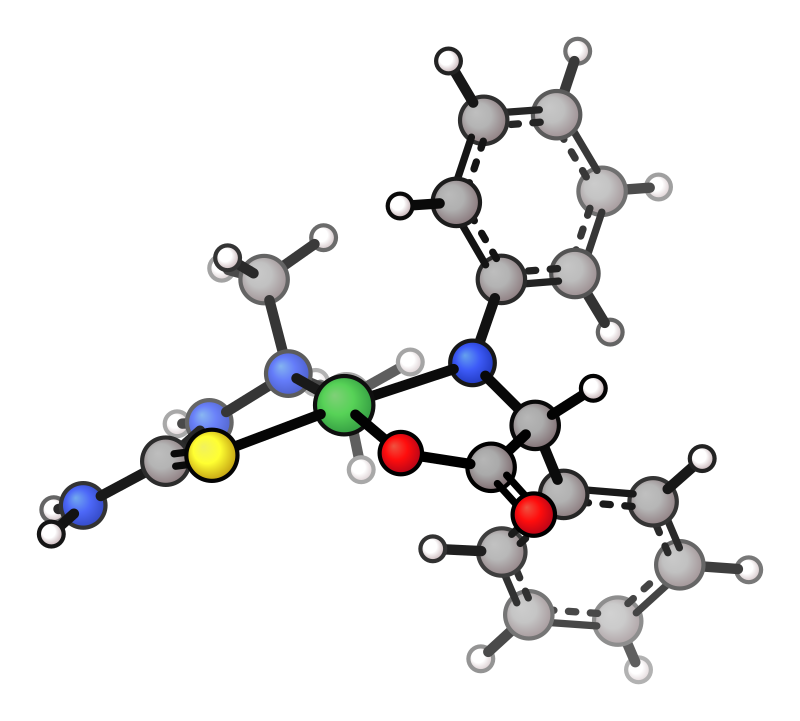

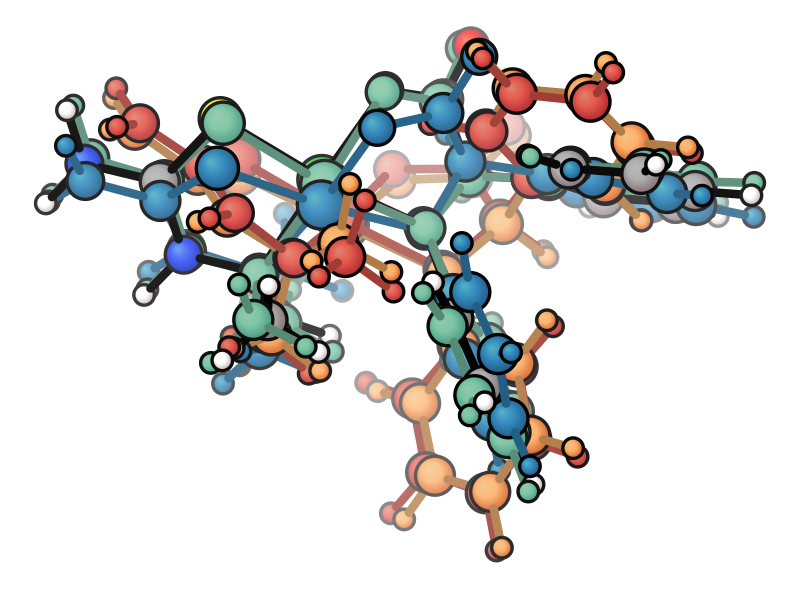

In [14]:
test = "C[N]1(C)NC(N)=[S]->[Ni+2]<-12<-[O-]C(=O)N(c1ccccc1)[CH-]->2c1ccccc1"
test = "C[N]1(C)NC(N)=[S]->[Ni+2]<-12<-[O-]C(=O)C(c1ccccc1)[N-]->2c1ccccc1"

en = rx.metal(test, "square_planar")
en.summary()
ens = rx.embed(en[3], n=5).minimize()
display(xyzrender.render(xyzrender.load(xyz(ens)), hy=True))
display(xyzrender.render(xyzrender.load(mxyz(ens), ensemble=True, ensemble_color="spectral")))

rxembed | metal: 1 undefined ligand stereocentre(s) -> enumerating coordination x 2 ligand stereoisomer(s) = 2 candidate(s) (select stereo=)


  [0] square_planar    P7 P2 O13 N23              (achiral)  stereo 16S
  [1] square_planar    P7 P2 O13 N23              (achiral)  stereo 16R


rxembed | embed[square_planar: P7 P2 O13 N23]: 1 seeds


embedding 
CC[P]1(CC)CC[P](CC)(CC)->[Ni+2]<-12<-[O-]C(=O)C(c1ccccc1)[N-]->2c1ccccc1
 square_planar | P7 P2 O13 N23 | achiral | stereo 16S
  M-donor: {'P7': 2.22, 'O13': 2.02, 'P2': 2.21, 'N23': 2.15}  | geom.check: FLAGGED


rxembed | minimize: relax ΔE spread (kcal/mol above min): [0.0] | window=250 -> all within window
rxembed | minimize: re-embedded to 1/1 clean geometries


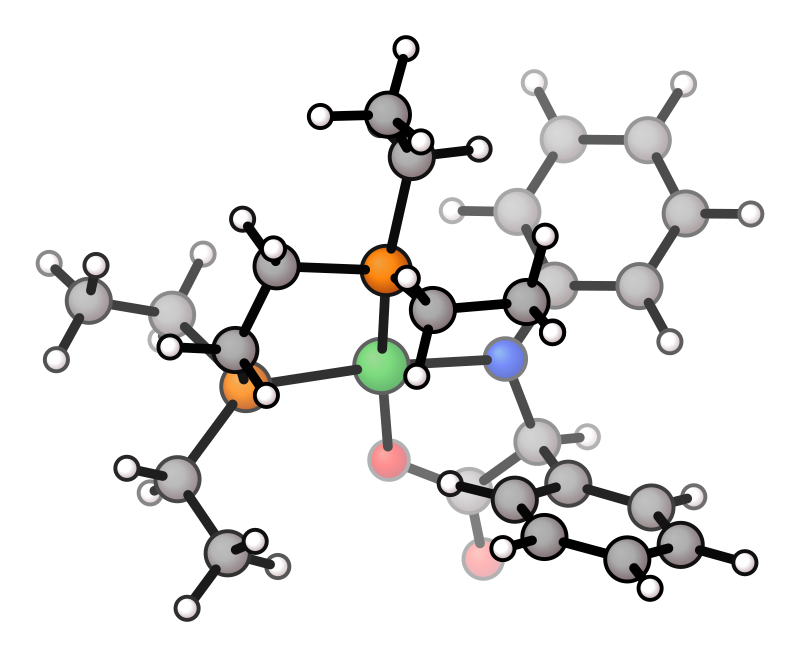

rxembed | embed[square_planar: P7 P2 O13 N23]: 1 seeds
rxembed | minimize: relax ΔE spread (kcal/mol above min): [0.0] | window=250 -> all within window


embedding 
CC[P]1(CC)CC[P](CC)(CC)->[Ni+2]<-12<-[O-]C(=O)C(c1ccccc1)[N-]->2c1ccccc1
 square_planar | P7 P2 O13 N23 | achiral | stereo 16R
  M-donor: {'P7': 2.21, 'O13': 2.02, 'P2': 2.21, 'N23': 2.15}  | geom.check: FLAGGED


rxembed | minimize: relax ΔE spread (kcal/mol above min): [0.0, 4.4, 13.9] | window=250 -> all within window
rxembed | minimize: re-embedded to 3/1 clean geometries


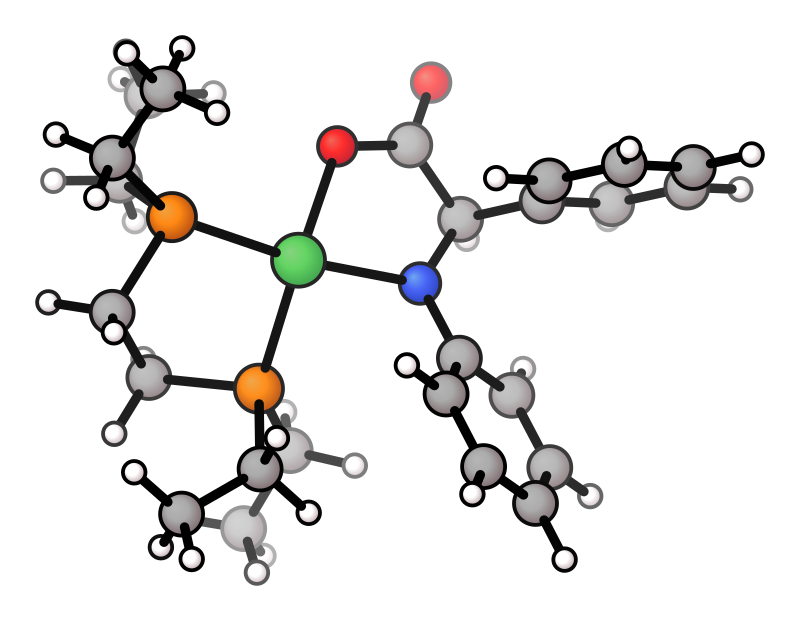

rxembed | metal: 1 undefined ligand stereocentre(s) -> enumerating coordination x 2 ligand stereoisomer(s) = 2 candidate(s) (select stereo=)
rxembed | embed[square_planar: P7 P2 O13 C23]: 1 seeds


  [0] square_planar    P7 P2 O13 C23              (achiral)  stereo 23R
  [1] square_planar    P7 P2 O13 C23              (achiral)  stereo 23S
embedding 
CC[P]1(CC)CC[P](CC)(CC)->[Ni+2]<-12<-[O-]C(=O)N(c1ccccc1)[CH-]->2c1ccccc1
 square_planar | P7 P2 O13 C23 | achiral | stereo 23R
  M-donor: {'P7': 2.22, 'O13': 2.06, 'P2': 2.23, 'C23': 2.29}  | geom.check: FLAGGED


rxembed | minimize: relax ΔE spread (kcal/mol above min): [0.0] | window=250 -> all within window
rxembed | minimize: re-embedded to 1/1 clean geometries


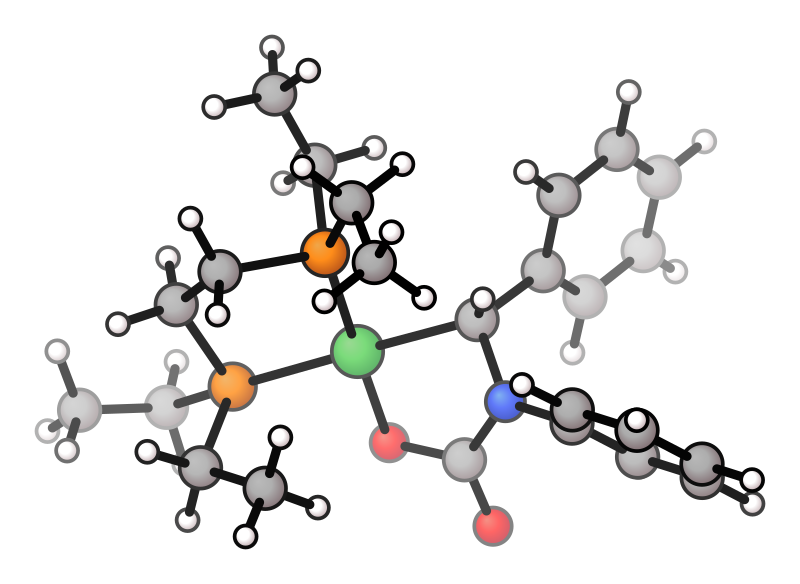

rxembed | embed[square_planar: P7 P2 O13 C23]: 1 seeds
rxembed | minimize: relax ΔE spread (kcal/mol above min): [0.0] | window=250 -> all within window
rxembed | minimize: re-embedded to 1/1 clean geometries


embedding 
CC[P]1(CC)CC[P](CC)(CC)->[Ni+2]<-12<-[O-]C(=O)N(c1ccccc1)[CH-]->2c1ccccc1
 square_planar | P7 P2 O13 C23 | achiral | stereo 23S
  M-donor: {'P7': 2.23, 'O13': 2.07, 'P2': 2.22, 'C23': 2.31}  | geom.check: FLAGGED


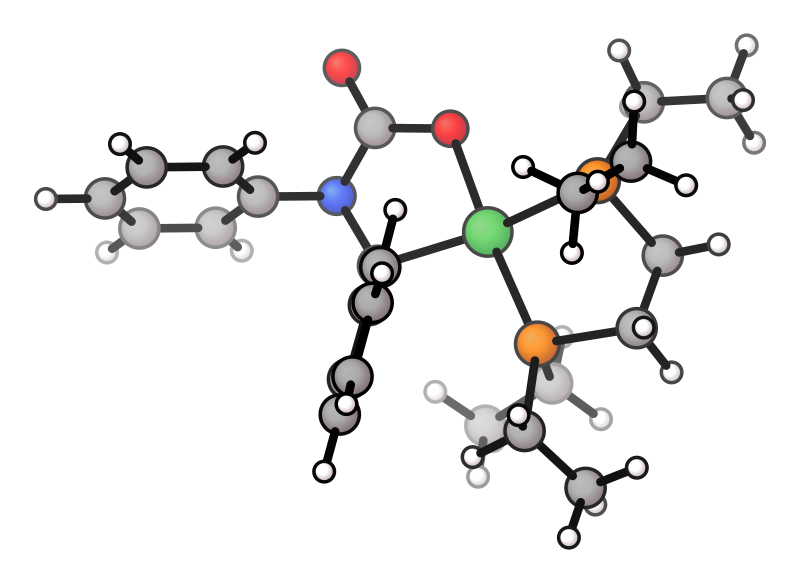

rxembed | metal: 1 undefined ligand stereocentre(s) -> enumerating coordination x 2 ligand stereoisomer(s) = 4 candidate(s) (select stereo=)


  [0] square_planar    S6 N1 O8 N18               (achiral)  stereo 11S
  [1] square_planar    S6 N1 N18 O8               (achiral)  stereo 11S
  [2] square_planar    S6 N1 O8 N18               (achiral)  stereo 11R
  [3] square_planar    S6 N1 N18 O8               (achiral)  stereo 11R


rxembed | embed[square_planar: S6 N1 O8 N18]: 1 seeds
rxembed | minimize: relax ΔE spread (kcal/mol above min): [0.0] | window=250 -> all within window
rxembed | minimize: re-embedded to 1/1 clean geometries


embedding 
C[N]1(C)NC(N)=[S]->[Ni+2]<-12<-[O-]C(=O)C(c1ccccc1)[N-]->2c1ccccc1
 square_planar | S6 N1 O8 N18 | achiral | stereo 11S
  M-donor: {'S6': 2.24, 'O8': 2.02, 'N1': 2.22, 'N18': 2.15}  | geom.check: FLAGGED


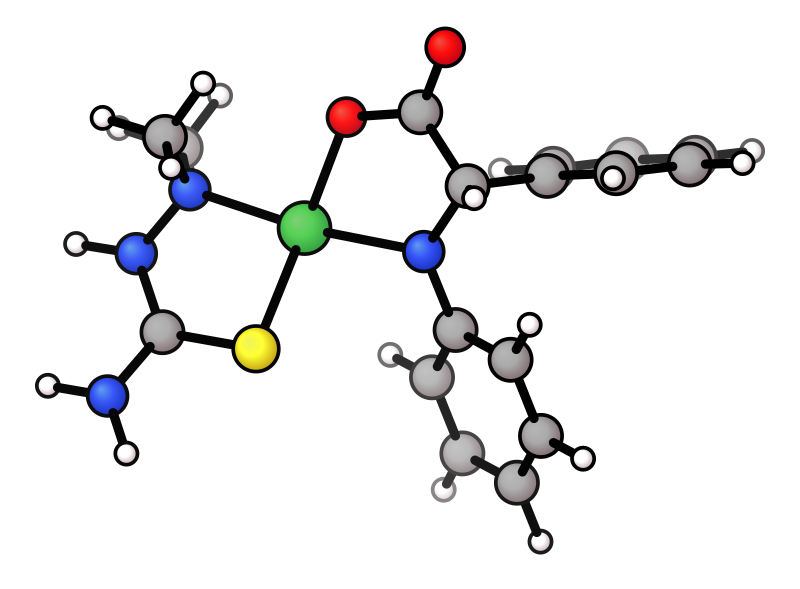

rxembed | embed[square_planar: S6 N1 N18 O8]: 1 seeds


embedding 
C[N]1(C)NC(N)=[S]->[Ni+2]<-12<-[O-]C(=O)C(c1ccccc1)[N-]->2c1ccccc1
 square_planar | S6 N1 N18 O8 | achiral | stereo 11S
  M-donor: {'S6': 2.24, 'O8': 2.02, 'N1': 2.21, 'N18': 2.15}  | geom.check: FLAGGED


rxembed | minimize: relax ΔE spread (kcal/mol above min): [0.0] | window=250 -> all within window
rxembed | minimize: relax ΔE spread (kcal/mol above min): [0.0, 1.7, 8909.4] | window=250 -> dropping 1 un-converged: [8909.4]
rxembed | minimize: dropped 1 conformer(s) with a broken bond, out-of-plane coordination sphere, or non-physical relax energy -> 2 kept
rxembed | minimize: re-embedded to 2/1 clean geometries


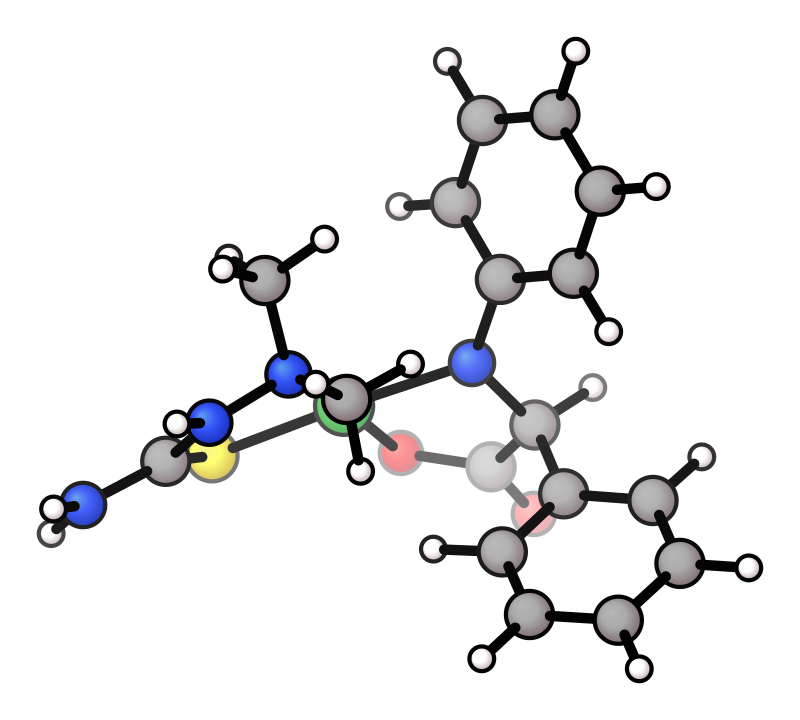

rxembed | embed[square_planar: S6 N1 O8 N18]: 1 seeds
rxembed | minimize: relax ΔE spread (kcal/mol above min): [0.0] | window=250 -> all within window
rxembed | minimize: re-embedded to 1/1 clean geometries


embedding 
C[N]1(C)NC(N)=[S]->[Ni+2]<-12<-[O-]C(=O)C(c1ccccc1)[N-]->2c1ccccc1
 square_planar | S6 N1 O8 N18 | achiral | stereo 11R
  M-donor: {'S6': 2.24, 'O8': 2.07, 'N1': 2.21, 'N18': 2.23}  | geom.check: FLAGGED


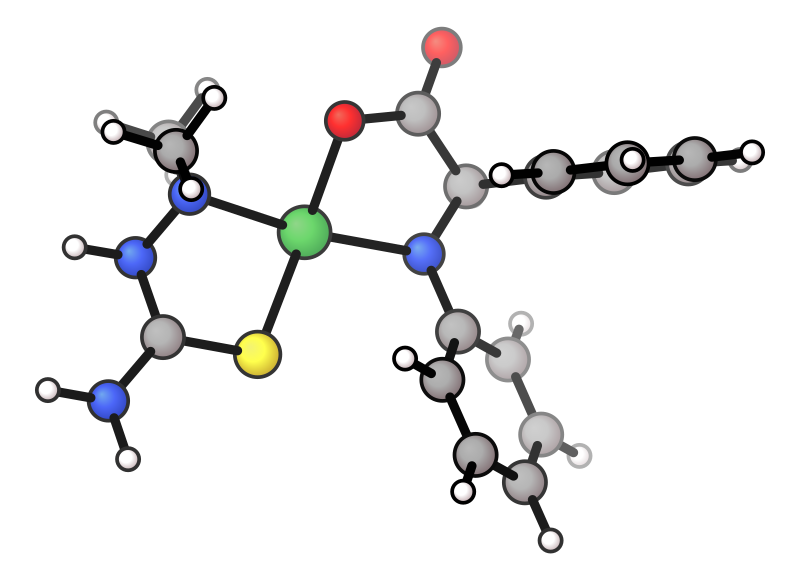

rxembed | embed[square_planar: S6 N1 N18 O8]: 1 seeds


embedding 
C[N]1(C)NC(N)=[S]->[Ni+2]<-12<-[O-]C(=O)C(c1ccccc1)[N-]->2c1ccccc1
 square_planar | S6 N1 N18 O8 | achiral | stereo 11R
  M-donor: {'S6': 2.24, 'O8': 2.02, 'N1': 2.21, 'N18': 2.15}  | geom.check: FLAGGED


rxembed | minimize: relax tore the sphere; escalated distance_fc to 3e+04
rxembed | minimize: relax ΔE spread (kcal/mol above min): [0.0] | window=250 -> all within window
rxembed | minimize: re-embedded to 1/1 clean geometries


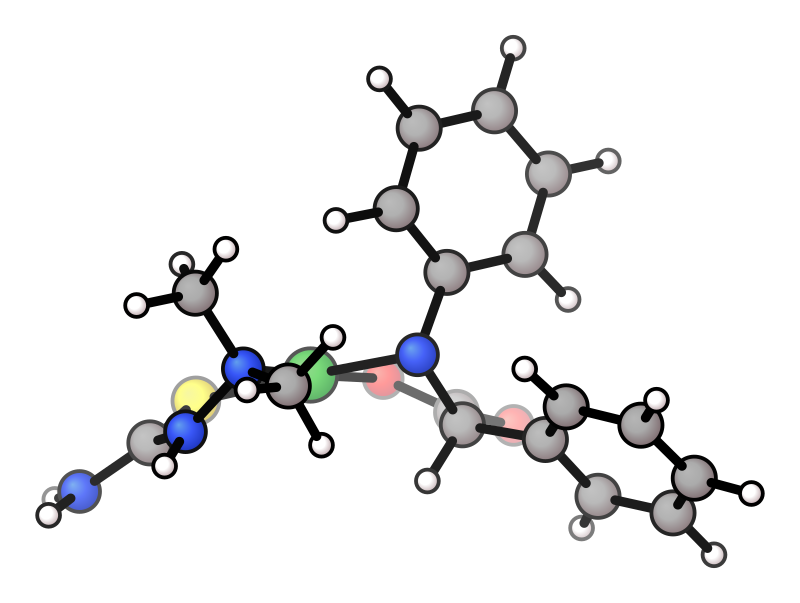

rxembed | metal: 1 undefined ligand stereocentre(s) -> enumerating coordination x 2 ligand stereoisomer(s) = 4 candidate(s) (select stereo=)
rxembed | embed[square_planar: S6 N1 O8 C18]: 1 seeds


  [0] square_planar    S6 N1 O8 C18               (achiral)  stereo 18R
  [1] square_planar    S6 N1 C18 O8               (achiral)  stereo 18R
  [2] square_planar    S6 N1 O8 C18               (achiral)  stereo 18S
  [3] square_planar    S6 N1 C18 O8               (achiral)  stereo 18S
embedding 
C[N]1(C)NC(N)=[S]->[Ni+2]<-12<-[O-]C(=O)N(c1ccccc1)[CH-]->2c1ccccc1
 square_planar | S6 N1 O8 C18 | achiral | stereo 18R
  M-donor: {'S6': 2.25, 'O8': 2.06, 'N1': 2.21, 'C18': 2.29}  | geom.check: FLAGGED


rxembed | minimize: relax ΔE spread (kcal/mol above min): [0.0] | window=250 -> all within window
rxembed | minimize: re-embedded to 1/1 clean geometries


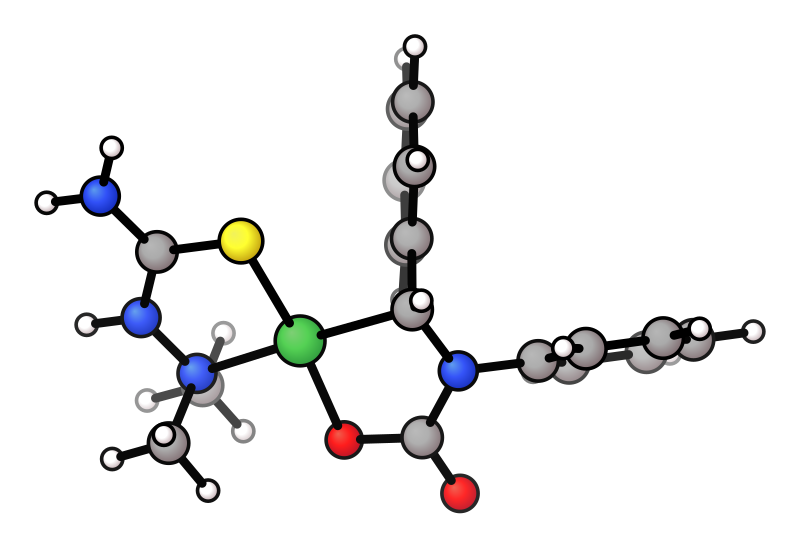

rxembed | embed[square_planar: S6 N1 C18 O8]: 1 seeds


embedding 
C[N]1(C)NC(N)=[S]->[Ni+2]<-12<-[O-]C(=O)N(c1ccccc1)[CH-]->2c1ccccc1
 square_planar | S6 N1 C18 O8 | achiral | stereo 18R
  M-donor: {'S6': 2.25, 'O8': 2.07, 'N1': 2.21, 'C18': 2.29}  | geom.check: FLAGGED


rxembed | minimize: relax ΔE spread (kcal/mol above min): [0.0] | window=250 -> all within window
rxembed | minimize: re-embedded to 1/1 clean geometries


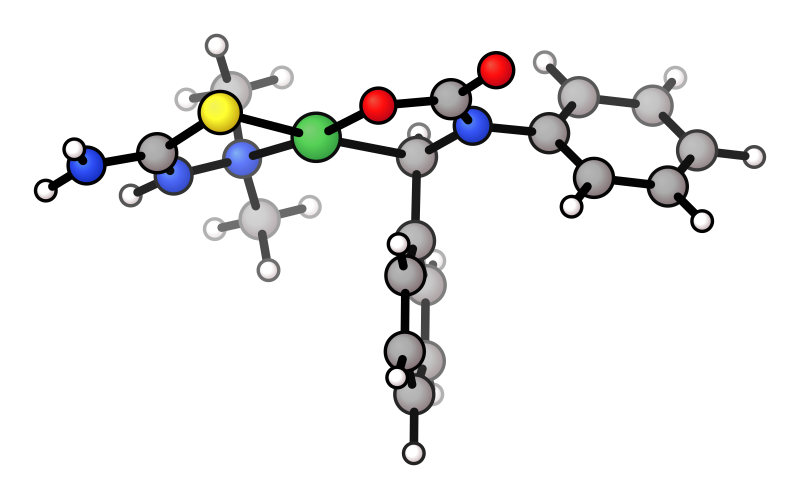

rxembed | embed[square_planar: S6 N1 O8 C18]: 1 seeds
rxembed | minimize: relax ΔE spread (kcal/mol above min): [0.0] | window=250 -> all within window


embedding 
C[N]1(C)NC(N)=[S]->[Ni+2]<-12<-[O-]C(=O)N(c1ccccc1)[CH-]->2c1ccccc1
 square_planar | S6 N1 O8 C18 | achiral | stereo 18S
  M-donor: {'S6': 2.25, 'O8': 2.05, 'N1': 2.21, 'C18': 2.31}  | geom.check: FLAGGED


rxembed | minimize: re-embedded to 1/1 clean geometries


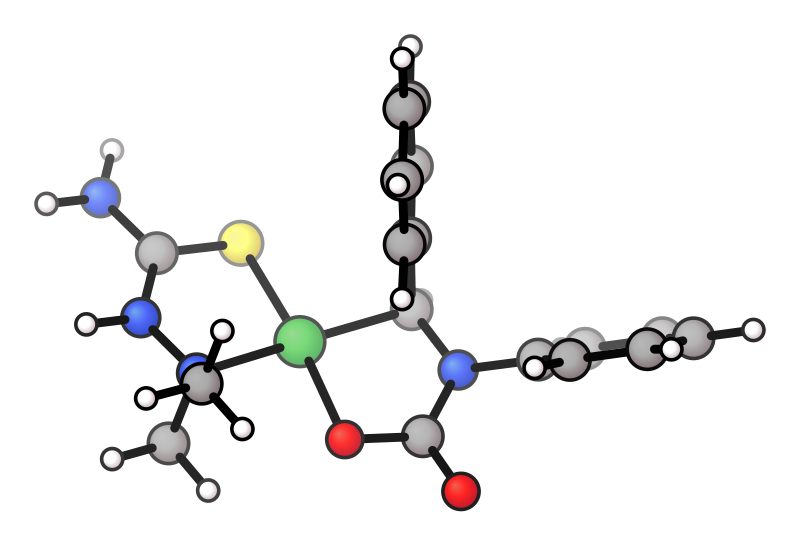

rxembed | embed[square_planar: S6 N1 C18 O8]: 1 seeds
rxembed | minimize: relax ΔE spread (kcal/mol above min): [0.0] | window=250 -> all within window


embedding 
C[N]1(C)NC(N)=[S]->[Ni+2]<-12<-[O-]C(=O)N(c1ccccc1)[CH-]->2c1ccccc1
 square_planar | S6 N1 C18 O8 | achiral | stereo 18S
  M-donor: {'S6': 2.22, 'O8': 2.23, 'N1': 2.21, 'C18': 2.32}  | geom.check: FLAGGED


rxembed | minimize: relax ΔE spread (kcal/mol above min): [0.0] | window=250 -> all within window
rxembed | minimize: dropped 2 conformer(s) with a broken bond, out-of-plane coordination sphere, or non-physical relax energy -> 1 kept
rxembed | minimize: re-embedded to 1/1 clean geometries


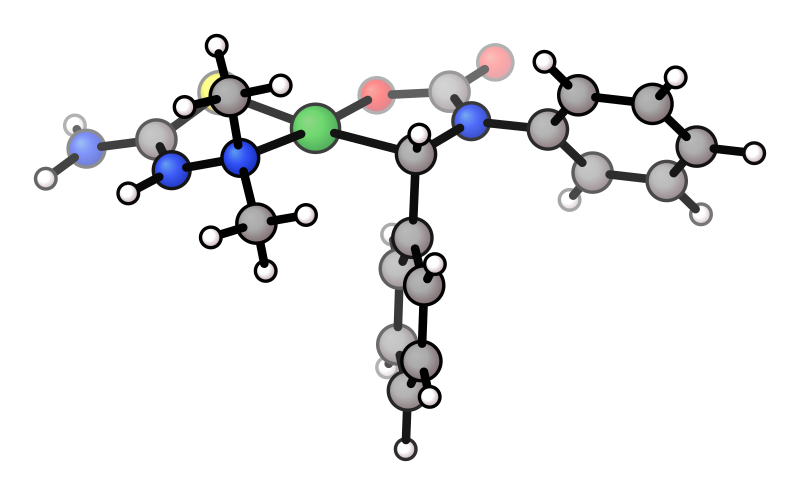

rxembed | metal: 1 undefined ligand stereocentre(s) -> enumerating coordination x 2 ligand stereoisomer(s) = 4 candidate(s) (select stereo=)


  [0] square_planar    N4 S25 O8 N18              (achiral)  stereo 11S
  [1] square_planar    N4 S25 N18 O8              (achiral)  stereo 11S
  [2] square_planar    N4 S25 O8 N18              (achiral)  stereo 11R
  [3] square_planar    N4 S25 N18 O8              (achiral)  stereo 11R


rxembed | embed[square_planar: N4 S25 O8 N18]: 1 seeds
rxembed | minimize: relax ΔE spread (kcal/mol above min): [0.0] | window=250 -> all within window


embedding 
CNC1N[N](C)(C)->[Ni+2]2(<-[O-]C(=O)C(c3ccccc3)[N-]->2c2ccccc2)<-[S]=1
 square_planar | N4 S25 O8 N18 | achiral | stereo 11S
  M-donor: {'N4': 2.22, 'O8': 2.03, 'S25': 2.25, 'N18': 2.19}  | geom.check: FLAGGED


rxembed | minimize: relax ΔE spread (kcal/mol above min): [0.0] | window=250 -> all within window
rxembed | minimize: dropped 2 conformer(s) with a broken bond, out-of-plane coordination sphere, or non-physical relax energy -> 1 kept
rxembed | minimize: re-embedded to 1/1 clean geometries


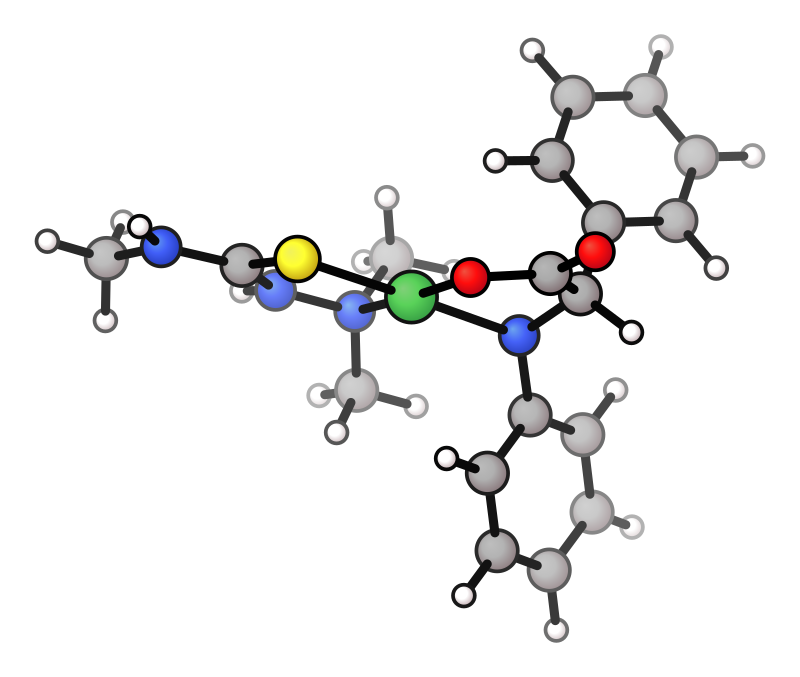

rxembed | embed[square_planar: N4 S25 N18 O8]: 1 seeds
rxembed | minimize: relax ΔE spread (kcal/mol above min): [0.0] | window=250 -> all within window
rxembed | minimize: re-embedded to 1/1 clean geometries


embedding 
CNC1N[N](C)(C)->[Ni+2]2(<-[O-]C(=O)C(c3ccccc3)[N-]->2c2ccccc2)<-[S]=1
 square_planar | N4 S25 N18 O8 | achiral | stereo 11S
  M-donor: {'N4': 2.21, 'O8': 2.03, 'S25': 2.25, 'N18': 2.18}  | geom.check: FLAGGED


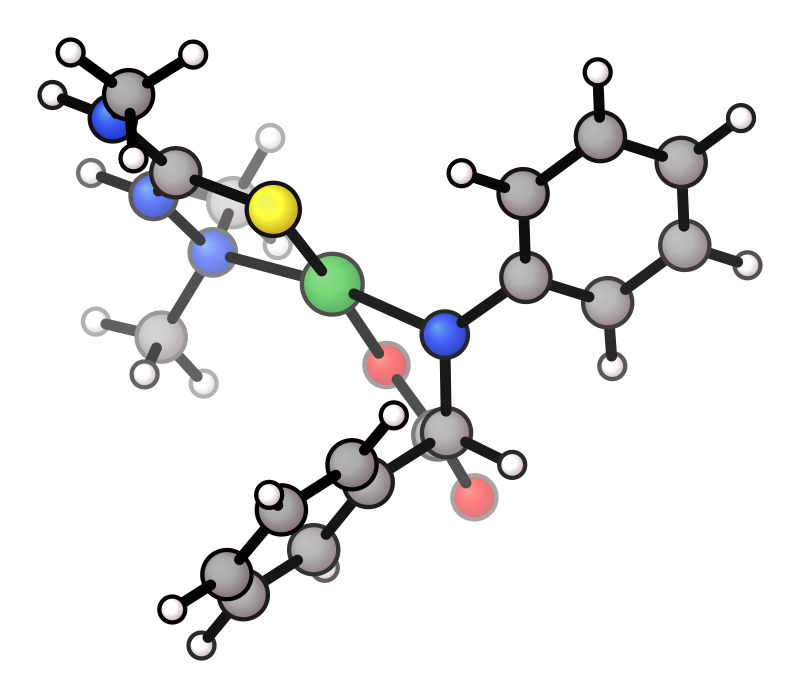

rxembed | embed[square_planar: N4 S25 O8 N18]: 1 seeds
rxembed | minimize: relax ΔE spread (kcal/mol above min): [0.0] | window=250 -> all within window
rxembed | minimize: re-embedded to 1/1 clean geometries


embedding 
CNC1N[N](C)(C)->[Ni+2]2(<-[O-]C(=O)C(c3ccccc3)[N-]->2c2ccccc2)<-[S]=1
 square_planar | N4 S25 O8 N18 | achiral | stereo 11R
  M-donor: {'N4': 2.21, 'O8': 2.02, 'S25': 2.25, 'N18': 2.15}  | geom.check: FLAGGED


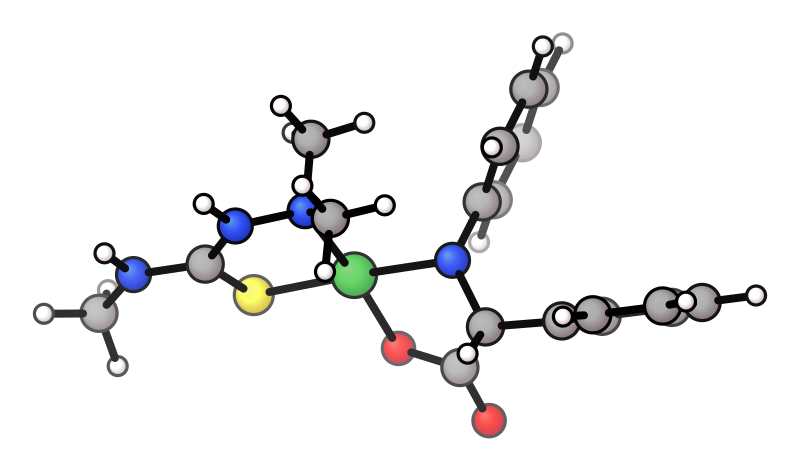

rxembed | embed[square_planar: N4 S25 N18 O8]: 1 seeds
rxembed | minimize: relax tore the sphere; escalated distance_fc to 1e+05
rxembed | minimize: relax ΔE spread (kcal/mol above min): [0.0] | window=250 -> all within window


embedding 
CNC1N[N](C)(C)->[Ni+2]2(<-[O-]C(=O)C(c3ccccc3)[N-]->2c2ccccc2)<-[S]=1
 square_planar | N4 S25 N18 O8 | achiral | stereo 11R
  M-donor: {'N4': 2.22, 'O8': 2.02, 'S25': 2.24, 'N18': 2.15}  | geom.check: FLAGGED


rxembed | minimize: relax ΔE spread (kcal/mol above min): [0.0, 4883.1] | window=250 -> dropping 1 un-converged: [4883.1]
rxembed | minimize: dropped 2 conformer(s) with a broken bond, out-of-plane coordination sphere, or non-physical relax energy -> 1 kept
rxembed | minimize: re-embedded to 1/1 clean geometries


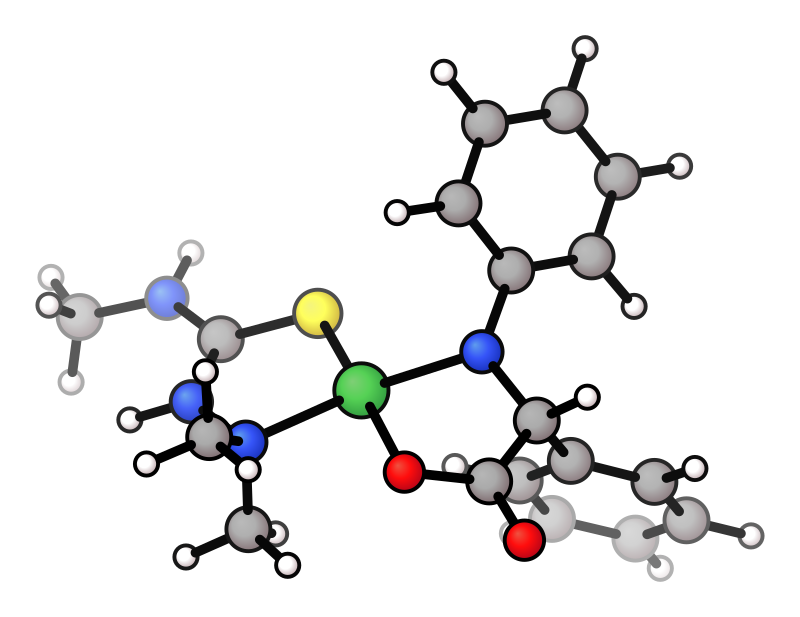

rxembed | metal: 1 undefined ligand stereocentre(s) -> enumerating coordination x 2 ligand stereoisomer(s) = 4 candidate(s) (select stereo=)
rxembed | embed[square_planar: N4 S25 O8 C18]: 1 seeds


  [0] square_planar    N4 S25 O8 C18              (achiral)  stereo 18R
  [1] square_planar    N4 S25 C18 O8              (achiral)  stereo 18R
  [2] square_planar    N4 S25 O8 C18              (achiral)  stereo 18S
  [3] square_planar    N4 S25 C18 O8              (achiral)  stereo 18S
embedding 
CNC1N[N](C)(C)->[Ni+2]2(<-[O-]C(=O)N(c3ccccc3)[CH-]->2c2ccccc2)<-[S]=1
 square_planar | N4 S25 O8 C18 | achiral | stereo 18R
  M-donor: {'N4': 2.2, 'O8': 2.06, 'S25': 2.26, 'C18': 2.29}  | geom.check: FLAGGED


rxembed | minimize: relax ΔE spread (kcal/mol above min): [0.0] | window=250 -> all within window
rxembed | minimize: re-embedded to 1/1 clean geometries


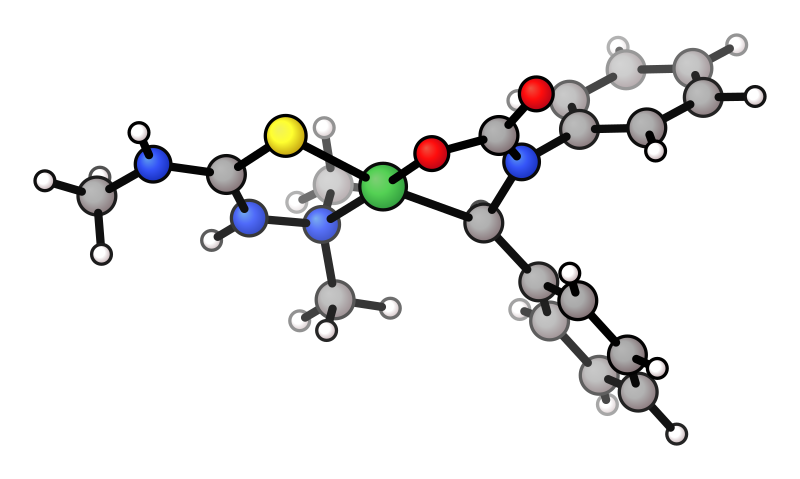

rxembed | embed[square_planar: N4 S25 C18 O8]: 1 seeds


embedding 
CNC1N[N](C)(C)->[Ni+2]2(<-[O-]C(=O)N(c3ccccc3)[CH-]->2c2ccccc2)<-[S]=1
 square_planar | N4 S25 C18 O8 | achiral | stereo 18R
  M-donor: {'N4': 2.2, 'O8': 2.06, 'S25': 2.25, 'C18': 2.31}  | geom.check: FLAGGED


rxembed | minimize: relax tore the sphere; escalated distance_fc to 3e+04
rxembed | minimize: relax ΔE spread (kcal/mol above min): [0.0] | window=250 -> all within window
rxembed | minimize: re-embedded to 1/1 clean geometries


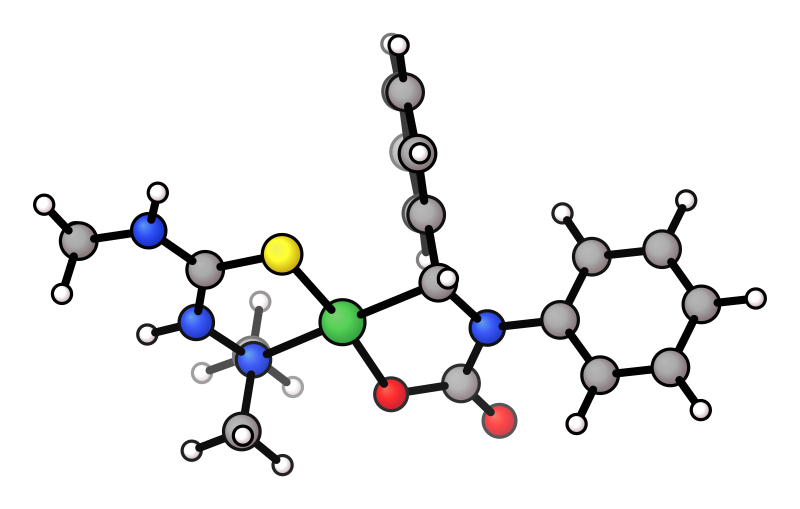

rxembed | embed[square_planar: N4 S25 O8 C18]: 1 seeds
rxembed | minimize: relax ΔE spread (kcal/mol above min): [0.0] | window=250 -> all within window
rxembed | minimize: re-embedded to 1/1 clean geometries


embedding 
CNC1N[N](C)(C)->[Ni+2]2(<-[O-]C(=O)N(c3ccccc3)[CH-]->2c2ccccc2)<-[S]=1
 square_planar | N4 S25 O8 C18 | achiral | stereo 18S
  M-donor: {'N4': 2.2, 'O8': 2.06, 'S25': 2.26, 'C18': 2.3}  | geom.check: FLAGGED


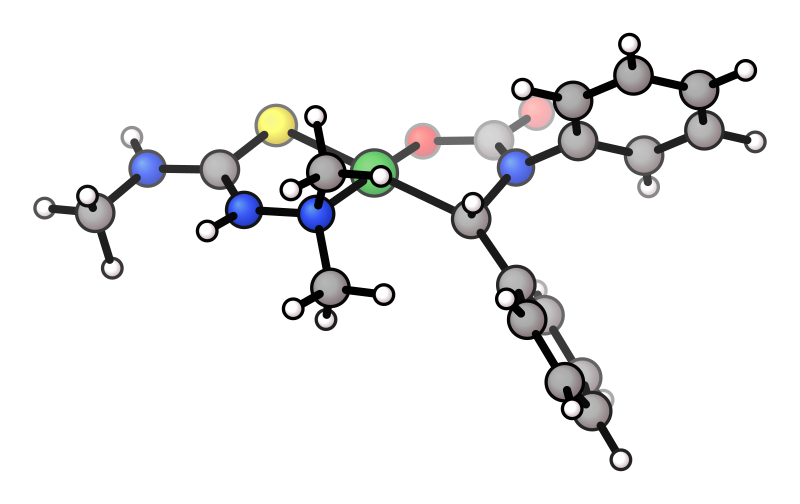

rxembed | embed[square_planar: N4 S25 C18 O8]: 1 seeds


embedding 
CNC1N[N](C)(C)->[Ni+2]2(<-[O-]C(=O)N(c3ccccc3)[CH-]->2c2ccccc2)<-[S]=1
 square_planar | N4 S25 C18 O8 | achiral | stereo 18S
  M-donor: {'N4': 2.2, 'O8': 2.06, 'S25': 2.25, 'C18': 2.29}  | geom.check: FLAGGED


rxembed | minimize: relax ΔE spread (kcal/mol above min): [0.0] | window=250 -> all within window
rxembed | minimize: re-embedded to 1/1 clean geometries


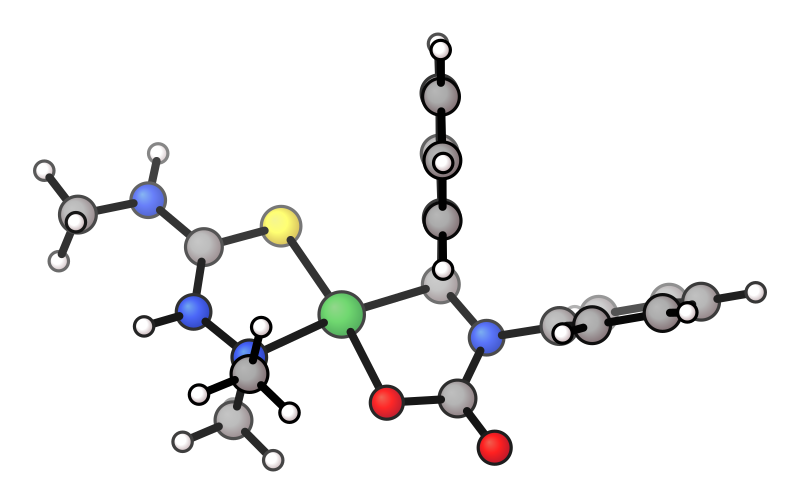

In [15]:
for i, smi_pair in enumerate(smi_pairs):
    if i > 2:
        continue
    for smi in smi_pair:
        en = rx.metal(smi, "square_planar")
        en.summary()
        for iso in en:
            ens = rx.embed(iso, n=1)
            try:
                if not ens.n:
                    print(f"embedding \n{smi}\n {iso.summary()}\n  (no conformer embedded)")
                    continue
                c = ens.mol.GetConformer(ens.ids[0])
                # sanity check: the M-donor bond lengths + the whole-molecule gate. NB a good M-donor set +
                # bonding_ok is NOT sufficient — the periphery (substituent orientation, planarity) can still be
                # bad; only geom.check catches that, which is why it's the real acceptance test.
                mdist = {
                    f"{ens.mol.GetAtomWithIdx(d).GetSymbol()}{d}": round(T.GetBondLength(c, iso.metal, d), 2)
                    for d in iso.donors
                }
                gate = "clean" if rx.geometry.check(ens.mol, ens.ids[0]).ok() else "FLAGGED"
                print(f"embedding \n{smi}\n {iso.summary()}\n  M-donor: {mdist}  | geom.check: {gate}")
                display(xyzrender.render(xyz(ens), hy=True, bo=False))  # each embedded isomer
            except Exception as e:
                print("  error", e)

## Full pipeline on one complex

One representative catalyst — a flexible benzyl-imine amidate — through the whole chain with the real inline
API: **embed a conformer set → view the ensemble → Monte-Carlo search around several seeds → prune duplicates
→ inspect the conformer diversity** at each stage. `landscape()` also draws the pruned-away duplicates faded,
so you see exactly what the cleanup collapsed.


rxembed | metal: 1 undefined ligand stereocentre(s) -> enumerating coordination x 2 ligand stereoisomer(s) = 2 candidate(s) (select stereo=)


  [0] square_planar    P7 P2 O13 N23              (achiral)  stereo 16S
  [1] square_planar    P7 P2 O13 N23              (achiral)  stereo 16R


rxembed | embed[square_planar: P7 P2 O13 N23]: 25 seeds
rxembed | minimize: relax ΔE spread (kcal/mol above min): [0.0, 0.1, 0.7, 3.1, 3.6, 3.6, 4.6, 5.2, 5.8, 6.3, 6.3, 6.6, 8.3, 8.3, 8.5, 12.9, 14.2, 15.4, 16.3, 20.8, 22.3, 43.4, 296380958280.3] | window=250 -> dropping 1 un-converged: [296380958280.3]
rxembed | minimize: dropped 3 conformer(s) with a broken bond, out-of-plane coordination sphere, or non-physical relax energy -> 22 kept
rxembed | minimize: relax ΔE spread (kcal/mol above min): [0.0, 5.1, 10.5, 10.6, 20.2] | window=250 -> all within window
rxembed | minimize: re-embedded to 27/25 clean geometries


embed(n=25) -> minimize: 25 conformers


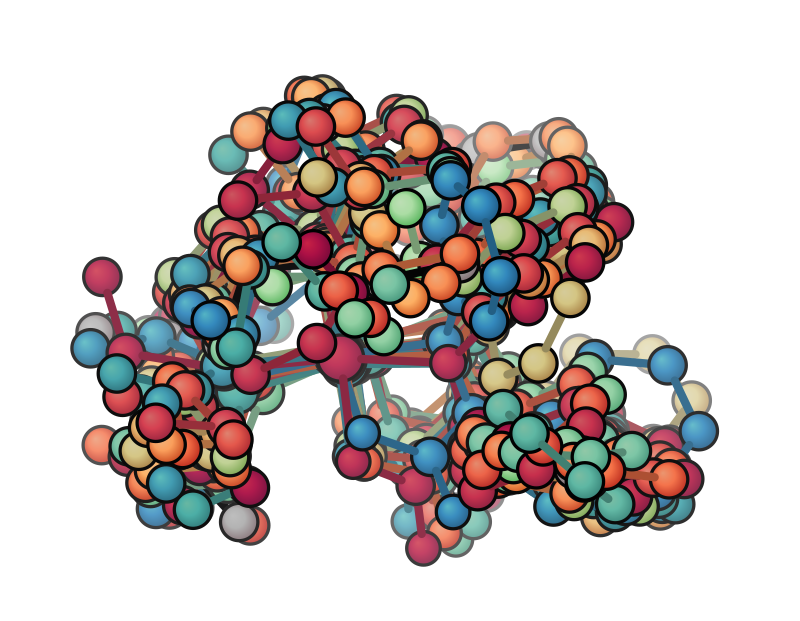

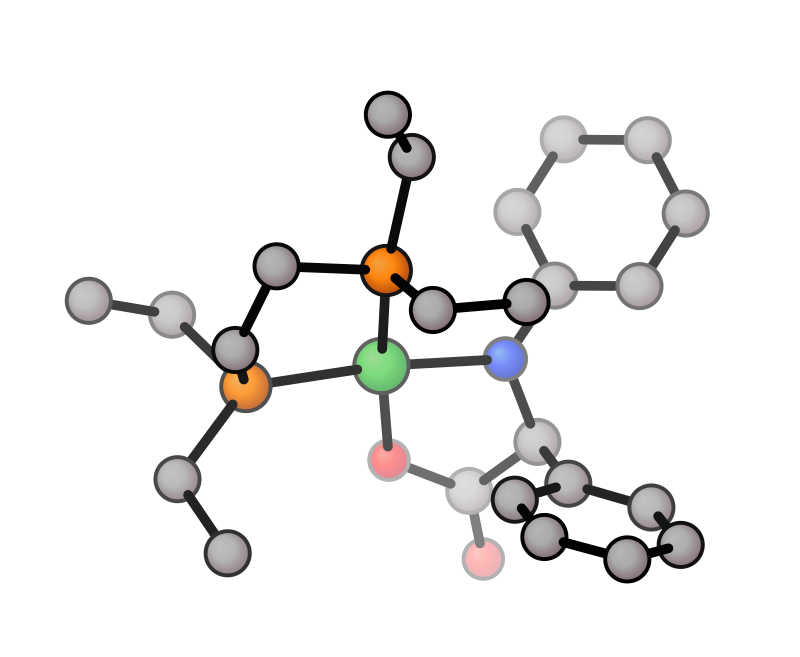

<Axes: xlabel='TSNE 1', ylabel='TSNE 2'>

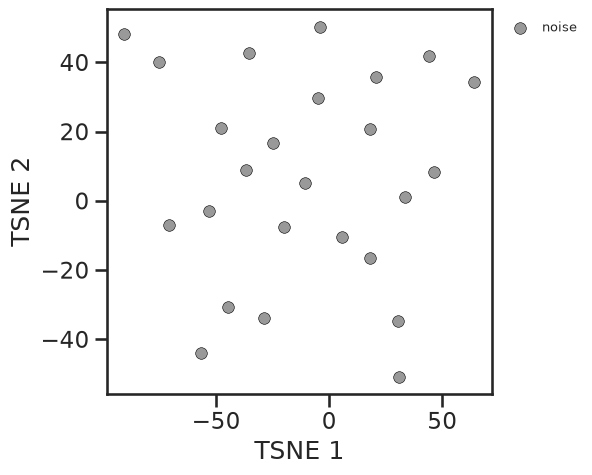

In [16]:
pipe_smi = "CC[P]1(CC)CC[P](CC)(CC)->[Ni+2]<-12<-[O-]C(=O)C(c1ccccc1)[N-]->2c1ccccc1"
iso = rx.metal(pipe_smi, "square_planar")
iso.summary()

ens = rx.embed(iso[0], n=25).minimize()  # 25 seeds -> edited-bounds embed -> restrained relax
print(f"embed(n=25) -> minimize: {ens.n} conformers")
display(
    xyzrender.render(xyzrender.load(mxyz(ens.align()), ensemble=True, ensemble_color="spectral"), no_hy=True, bo=False)
)  # all conformers, aligned
display(xyzrender.render(xyzrender.load(mxyz(ens.align())), no_hy=True, bo=False))  # all conformers, aligned
ens.landscape(method="tsne")  # conformer diversity of the raw embed set

rxembed | embed[square_planar: P7 P2 O13 N23]: 10 seeds
rxembed | minimize: relax ΔE spread (kcal/mol above min): [0.0, 0.7, 3.1, 4.6, 5.2, 5.8, 6.3, 20.8, 43.4, 296380958280.3] | window=250 -> dropping 1 un-converged: [296380958280.3]
rxembed | minimize: dropped 1 conformer(s) with a broken bond, out-of-plane coordination sphere, or non-physical relax energy -> 9 kept
rxembed | minimize: relax ΔE spread (kcal/mol above min): [0.0, 10.6, 20.2] | window=250 -> all within window
rxembed | minimize: re-embedded to 12/10 clean geometries
rxembed | mc: 7 atom(s) constrained -> openconf runs POSE-FROZEN (rotor-only; low-mode/ring/global moves off) so the held contact is never broken
rxembed | mc: +84 (openconf 'transition_metal', pose-constrained around seeds; total 94)
rxembed | minimize: relax ΔE spread (kcal/mol above min): [0.0, 0.7, 0.7, 1.1, 1.5, 1.9, 2.2, 2.6, 2.8, 3.2, 4.6, 4.6, 4.6, 4.6, 4.7, 4.8, 5.2, 5.4, 5.4, 5.8, 5.8, 6.1, 6.3, 6.4, 6.4, 6.4, 6.4, 6.5, 6.5, 6.5, 6.6, 6.6, 6.6, 6

embed(n=10) -> minimize -> mc(transition_metal): 93 conformers


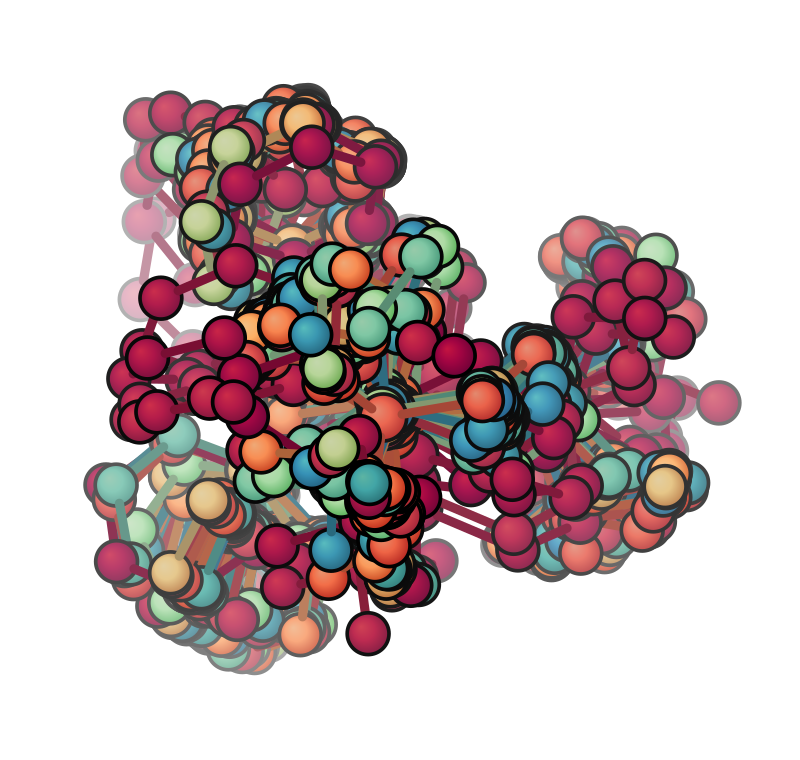

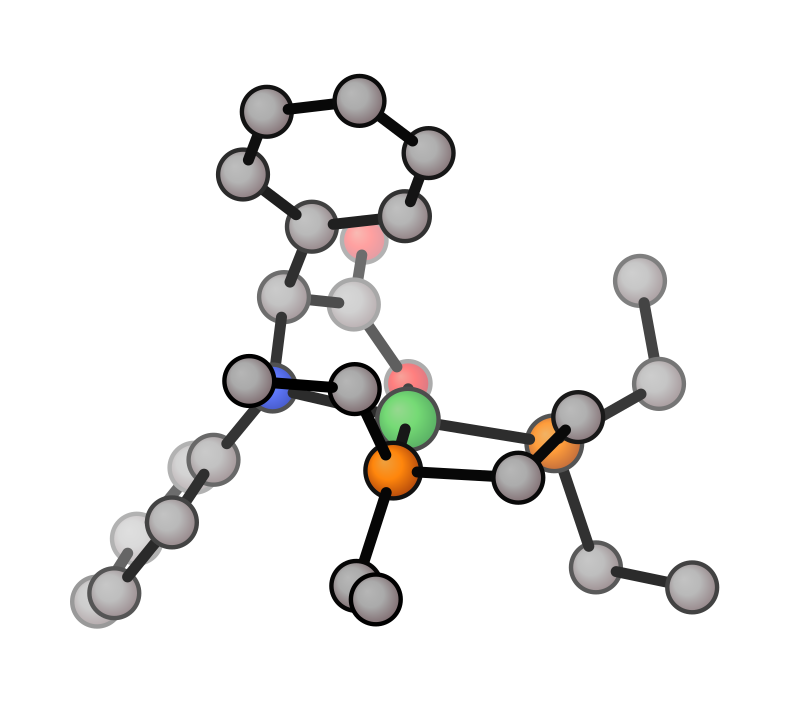

<Axes: xlabel='PCA 1', ylabel='PCA 2'>

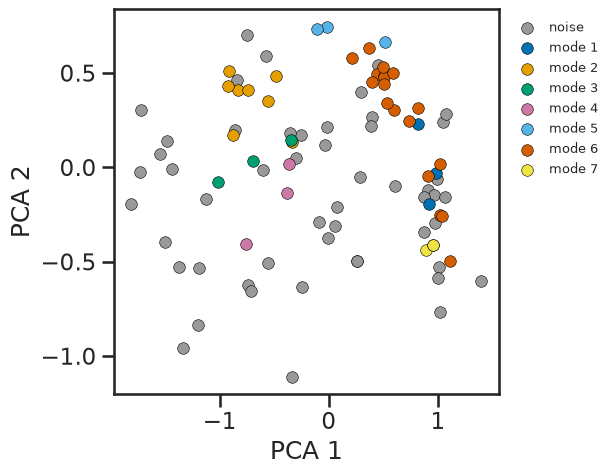

In [17]:
searched = (
    rx.embed(iso[0], n=10).minimize().mc(preset="transition_metal").minimize()
)  # 5 seeds -> MC torsional search around each
print(f"embed(n=10) -> minimize -> mc(transition_metal): {searched.n} conformers")
display(
    xyzrender.render(
        xyzrender.load(mxyz(searched.align()), ensemble=True, ensemble_color="spectral"), no_hy=True, bo=False
    )
)

display(xyzrender.render(xyzrender.load(mxyz(searched)), no_hy=True, bo=False))
searched.landscape()

rxembed | prune[rmsd]: 93 -> 60  (merged 33 near-duplicates; see .duplicates())


prune: 93 -> 60 conformers  (33 duplicates removed)


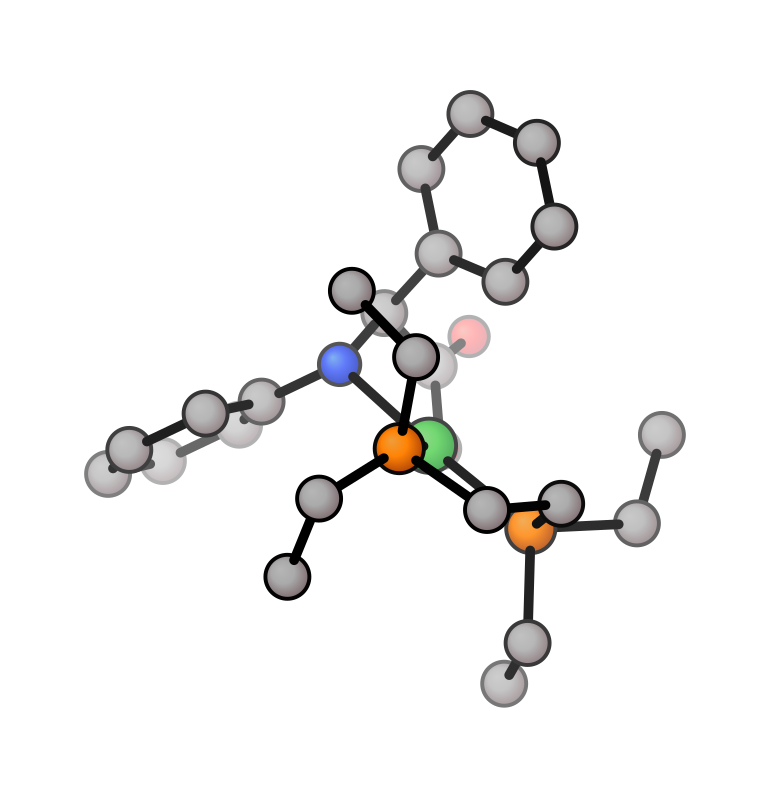

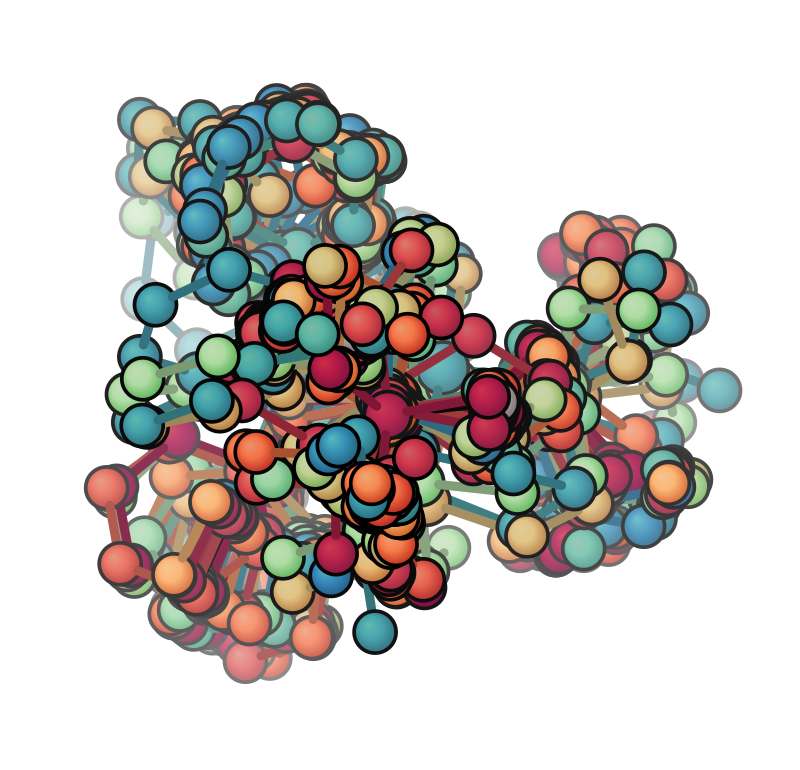

<Axes: xlabel='PCA 1', ylabel='PCA 2'>

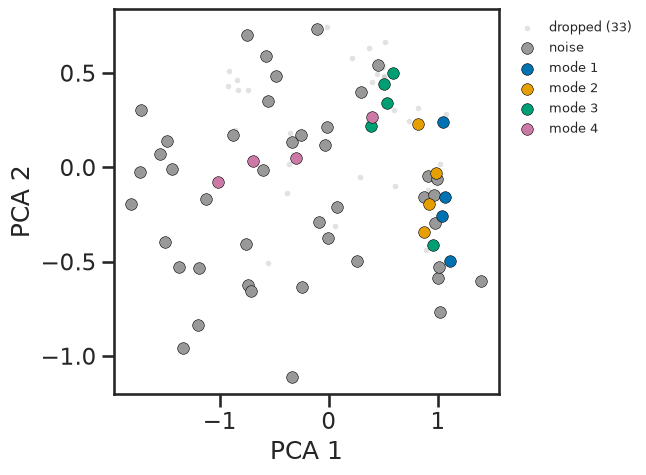

In [18]:
before = searched.n
searched.prune()  # dedup: moment-of-inertia / RMSD / descriptor prune
print(f"prune: {before} -> {searched.n} conformers  ({before - searched.n} duplicates removed)")
display(xyzrender.render(mxyz(searched.align()), no_hy=True, bo=False))
display(
    xyzrender.render(
        xyzrender.load(mxyz(searched.align()), ensemble=True, ensemble_color="spectral"), no_hy=True, bo=False
    )
)
searched.landscape()  # kept representatives (solid) + the pruned-away duplicates (faded), one space

## Stereo enumeration — the racemate (R/S)

The amidate α-carbon (the `C(c1ccccc1)` between the carbonyl and the metal-bound `[N-]`) is a stereocentre the
SMILES leaves unspecified. By default (`stereo='racemic'`) rxembed **enumerates it and embeds both hands** — the
log states the decision (`… undefined ligand stereocentre(s) -> … ligand stereoisomer(s)`) and each candidate's
`.tag` carries the `16R` / `16S` CIP label. `rx.embed(smi, metal=…)` folds them into one **chainable
`EnsembleSet`**: every verb (`mc`/`minimize`/`prune`/`score`/`dump`) maps over each hand, on its own constraints.
A metal-bound centre is a stereocentre only *while* bound, so its hand is **pinned across embed → mc → minimize**
(not left to the surrogate to invert). The two hands are distinct species — **never energy-pruned against each
other**; ranking them is a deliberate step needing REAL energies (`.score('gxtb').best()`, which refuses FF).

rxembed | metal: 1 undefined ligand stereocentre(s) -> enumerating coordination x 2 ligand stereoisomer(s) = 2 candidate(s) (select stereo=)
rxembed | embed[square_planar: P7 P2 O13 N23]: 6 seeds
rxembed | embed[square_planar: P7 P2 O13 N23]: 6 seeds
rxembed | metal: ENUMERATING isomers of square_planar -> 2 distinct candidate(s) (each a separate ensemble; .summary() / .select() one to conf-search)
rxembed | EnsembleSet.minimize: applied to 2 candidate(s) [16S_cis, 16R_cis] independently — WITHIN each (own constraints); distinct species are never pooled/cross-pruned
rxembed | minimize: relax ΔE spread (kcal/mol above min): [0.0, 2.4, 4.5, 5.7, 20.2, 42.8] | window=250 -> all within window
rxembed | minimize: re-embedded to 6/6 clean geometries
rxembed | minimize: relax ΔE spread (kcal/mol above min): [0.0, 4.8, 7.9, 19.4, 895.8, 296380689444.5] | window=250 -> dropping 2 un-converged: [895.8, 296380689444.5]
rxembed | minimize: dropped 2 conformer(s) with a broken bond, out-of-plane co

stereo 16S: 6 conformers | geom.check: clean


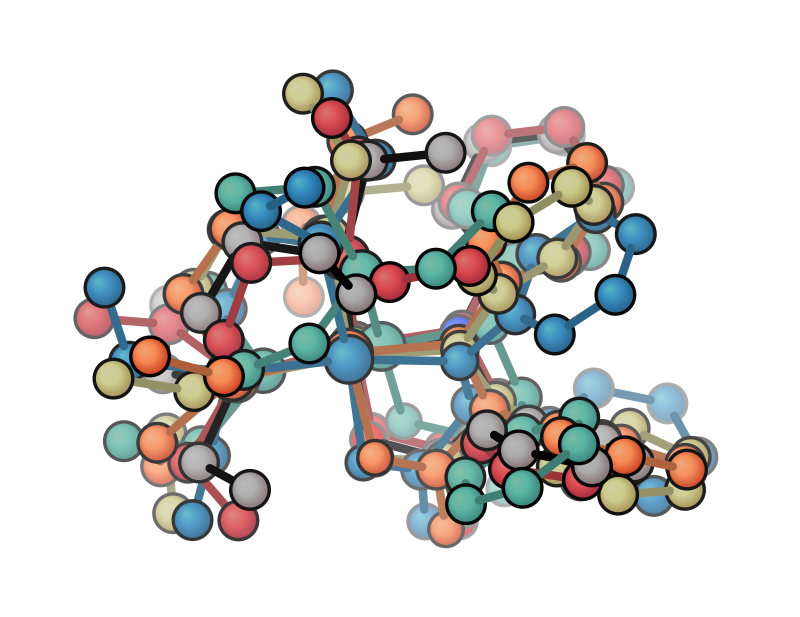

stereo 16R: 6 conformers | geom.check: clean


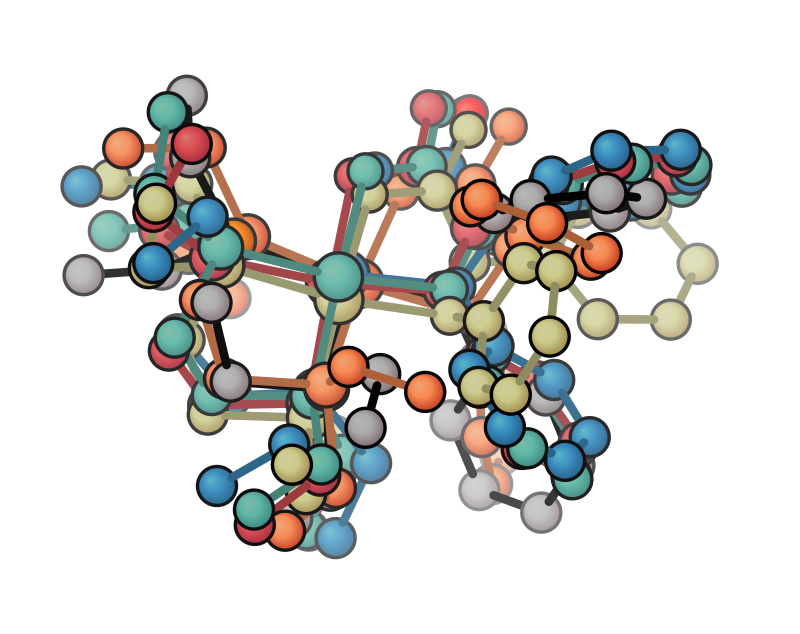

dumped one file per hand: ['henry_16S_cis.xyz', 'henry_16R_cis.xyz']


In [19]:
# both enantiomers + the whole chain, per hand — one call returns a chainable EnsembleSet (16R / 16S tagged)
racemate = (
    rx.embed(pipe_smi, metal="square_planar", n=6).minimize().prune()
)  # add .mc(preset="transition_metal") for a full search
for e in racemate:  # each hand carried its 16R/16S tag through the whole chain, on its own constraints
    gate = "clean" if all(rx.geometry.check(e.mol, c).ok() for c in e.ids) else "FLAGGED"
    print(f"stereo {e.tag['stereo']}: {e.n} conformers | geom.check: {gate}")
    display(
        xyzrender.render(
            xyzrender.load(mxyz(e.align()), ensemble=e.n > 1, ensemble_color="spectral"), no_hy=True, bo=False
        )
    )

paths = racemate.dump(tempfile.mkdtemp() + "/henry.xyz")  # one tagged .xyz per enantiomer
print("dumped one file per hand:", [p.split("/")[-1] for p in paths])

# Ranking the two hands is the ONE deliberate cross-species step and needs REAL energies (xtb on $XTB_EXE) —
# FF surrogate totals are not comparable across stereoisomers, so best() refuses them:
#   best_hand = racemate.score("gxtb").best()   # enantiomers share a formula, so g-xTB totals DO compare